In [138]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

In [3]:
df_tarin_clean = pd.read_csv(r"../data/raw/train.csv")

df_tarin_clean

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [4]:
train_null_val =[(col,df_tarin_clean[col].isnull().sum()) for col in df_tarin_clean.columns if df_tarin_clean[col].isnull().sum() != 0]

train_null_val

[('LotFrontage', np.int64(259)),
 ('Alley', np.int64(1369)),
 ('MasVnrType', np.int64(872)),
 ('MasVnrArea', np.int64(8)),
 ('BsmtQual', np.int64(37)),
 ('BsmtCond', np.int64(37)),
 ('BsmtExposure', np.int64(38)),
 ('BsmtFinType1', np.int64(37)),
 ('BsmtFinType2', np.int64(38)),
 ('Electrical', np.int64(1)),
 ('FireplaceQu', np.int64(690)),
 ('GarageType', np.int64(81)),
 ('GarageYrBlt', np.int64(81)),
 ('GarageFinish', np.int64(81)),
 ('GarageQual', np.int64(81)),
 ('GarageCond', np.int64(81)),
 ('PoolQC', np.int64(1453)),
 ('Fence', np.int64(1179)),
 ('MiscFeature', np.int64(1406))]

In [5]:
df_tarin_clean['Alley'].unique()

<StringArray>
[nan, 'Grvl', 'Pave']
Length: 3, dtype: str

In [6]:
#filling the lotfrontage missing value iwth the median and stroe it in the variavle
"""_summary_
1.lot_frontage_median -- median for lotfrontage 
    """

'_summary_\n1.lot_frontage_median -- median for lotfrontage \n    '

In [7]:
lot_frontage_median = df_tarin_clean['LotFrontage'].median()

lot_frontage_median

np.float64(69.0)

In [8]:
df_tarin_clean['LotFrontage'] = df_tarin_clean['LotFrontage'].fillna(lot_frontage_median)

In [9]:
#alley
#filled with No Alley

In [10]:
df_tarin_clean['Alley'] = df_tarin_clean['Alley'].fillna("No Alley")

df_tarin_clean['Alley'].isnull().sum()

df_tarin_clean["Alley"].unique()

<StringArray>
['No Alley', 'Grvl', 'Pave']
Length: 3, dtype: str

In [11]:
#masvnr type 
#it tells about brick stone

#filled with None

In [12]:
df_tarin_clean['MasVnrType'].unique()

<StringArray>
['BrkFace', nan, 'Stone', 'BrkCmn']
Length: 4, dtype: str

In [13]:
df_tarin_clean['MasVnrType'] = df_tarin_clean['MasVnrType'].fillna("None")

In [14]:
df_tarin_clean['MasVnrType'].unique()

<StringArray>
['BrkFace', 'None', 'Stone', 'BrkCmn']
Length: 4, dtype: str

In [15]:
#the are outside 
#it have 8 nan so fill it with 0 bcz it dont have outside area

In [16]:
df_tarin_clean['MasVnrArea'] = df_tarin_clean['MasVnrArea'].fillna(0)

In [17]:
#basement quality

#fill nan with None

In [18]:
df_tarin_clean["BsmtQual"]

0       Gd
1       Gd
2       Gd
3       TA
4       Gd
        ..
1455    Gd
1456    Gd
1457    TA
1458    TA
1459    TA
Name: BsmtQual, Length: 1460, dtype: str

In [19]:
df_tarin_clean["BsmtQual"] = df_tarin_clean["BsmtQual"].fillna('None')

In [20]:
df_tarin_clean["BsmtQual"].isnull().sum()
df_tarin_clean["BsmtQual"].unique()

<StringArray>
['Gd', 'TA', 'Ex', 'None', 'Fa']
Length: 5, dtype: str

In [21]:
#BsmtCond
#basement condition rn
#filled with the None

df_tarin_clean['BsmtCond'].unique()
df_tarin_clean['BsmtCond'] = df_tarin_clean['BsmtCond'].fillna("None")
df_tarin_clean['BsmtCond'].isnull().sum()
df_tarin_clean['BsmtCond'].unique()

<StringArray>
['TA', 'Gd', 'None', 'Fa', 'Po']
Length: 5, dtype: str

In [22]:
#filled the bsmt exposure with no for nan values

In [23]:
df_tarin_clean.loc[df_tarin_clean['BsmtExposure'].isna(),["BsmtQual","BsmtExposure"]]

df_tarin_clean["BsmtExposure"] = df_tarin_clean["BsmtExposure"].fillna("No")

In [24]:
df_tarin_clean["BsmtExposure"].unique()

<StringArray>
['No', 'Gd', 'Mn', 'Av']
Length: 4, dtype: str

In [25]:
train_null_val

[('LotFrontage', np.int64(259)),
 ('Alley', np.int64(1369)),
 ('MasVnrType', np.int64(872)),
 ('MasVnrArea', np.int64(8)),
 ('BsmtQual', np.int64(37)),
 ('BsmtCond', np.int64(37)),
 ('BsmtExposure', np.int64(38)),
 ('BsmtFinType1', np.int64(37)),
 ('BsmtFinType2', np.int64(38)),
 ('Electrical', np.int64(1)),
 ('FireplaceQu', np.int64(690)),
 ('GarageType', np.int64(81)),
 ('GarageYrBlt', np.int64(81)),
 ('GarageFinish', np.int64(81)),
 ('GarageQual', np.int64(81)),
 ('GarageCond', np.int64(81)),
 ('PoolQC', np.int64(1453)),
 ('Fence', np.int64(1179)),
 ('MiscFeature', np.int64(1406))]

In [26]:
#filled the bsmtfinish type 1 nan values with the no

In [27]:
df_tarin_clean["BsmtFinType1"] = df_tarin_clean["BsmtFinType1"].fillna("No")

df_tarin_clean["BsmtFinType1"].unique()

<StringArray>
['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', 'No', 'LwQ']
Length: 7, dtype: str

In [28]:
#filled the bsmtfinish type 2 nan values with the no

In [29]:
df_tarin_clean["BsmtFinType2"] = df_tarin_clean["BsmtFinType2"].fillna("No")
df_tarin_clean["BsmtFinType2"].unique()

<StringArray>
['Unf', 'BLQ', 'No', 'ALQ', 'Rec', 'LwQ', 'GLQ']
Length: 7, dtype: str

In [30]:
#electrical column have one missing vales so gonna fill it with mode 0

In [31]:
df_tarin_clean["Electrical"].unique()

df_tarin_clean["Electrical"] = df_tarin_clean["Electrical"].fillna(df_tarin_clean["Electrical"].mode()[0])

df_tarin_clean["Electrical"].unique()

df_tarin_clean["Electrical"].isnull().sum()

np.int64(0)

In [32]:
#filling the fireplace condition with non cuz all house may not have fireplace 
#No

In [33]:
df_tarin_clean["FireplaceQu"].unique()

df_tarin_clean["FireplaceQu"] = df_tarin_clean["FireplaceQu"].fillna("No")
df_tarin_clean["FireplaceQu"].unique(),df_tarin_clean["FireplaceQu"].isnull().sum()

(<StringArray>
 ['No', 'TA', 'Gd', 'Fa', 'Ex', 'Po']
 Length: 6, dtype: str,
 np.int64(0))

In [34]:
df_tarin_clean.loc[df_tarin_clean["GarageYrBlt"].isna(),['GarageType','GarageYrBlt','GarageFinish','GarageQual','GarageCond']].to_dict()

{'GarageType': {39: nan,
  48: nan,
  78: nan,
  88: nan,
  89: nan,
  99: nan,
  108: nan,
  125: nan,
  127: nan,
  140: nan,
  148: nan,
  155: nan,
  163: nan,
  165: nan,
  198: nan,
  210: nan,
  241: nan,
  250: nan,
  287: nan,
  291: nan,
  307: nan,
  375: nan,
  386: nan,
  393: nan,
  431: nan,
  434: nan,
  441: nan,
  464: nan,
  495: nan,
  520: nan,
  528: nan,
  533: nan,
  535: nan,
  562: nan,
  582: nan,
  613: nan,
  614: nan,
  620: nan,
  635: nan,
  636: nan,
  638: nan,
  649: nan,
  705: nan,
  710: nan,
  738: nan,
  750: nan,
  784: nan,
  826: nan,
  843: nan,
  921: nan,
  942: nan,
  954: nan,
  960: nan,
  968: nan,
  970: nan,
  976: nan,
  1009: nan,
  1011: nan,
  1030: nan,
  1038: nan,
  1096: nan,
  1123: nan,
  1131: nan,
  1137: nan,
  1143: nan,
  1173: nan,
  1179: nan,
  1218: nan,
  1219: nan,
  1234: nan,
  1257: nan,
  1283: nan,
  1323: nan,
  1325: nan,
  1326: nan,
  1337: nan,
  1349: nan,
  1407: nan,
  1449: nan,
  1450: nan,
  1453: 

In [35]:
#filled grage type with No 
#cuz all home may not have grage

In [36]:
df_tarin_clean["GarageType"].isnull().sum(),df_tarin_clean["GarageType"].unique()

df_tarin_clean["GarageType"] = df_tarin_clean["GarageType"].fillna("No")

df_tarin_clean["GarageType"].isnull().sum(),df_tarin_clean["GarageType"].unique()

(np.int64(0),
 <StringArray>
 ['Attchd', 'Detchd', 'BuiltIn', 'CarPort', 'No', 'Basment', '2Types']
 Length: 7, dtype: str)

In [37]:
#grage buit is chnaged no for nan values 0
#chnaging dtype to int

In [38]:
df_tarin_clean['GarageYrBlt'] = df_tarin_clean["GarageYrBlt"].fillna(0)

df_tarin_clean["GarageYrBlt"].unique()

df_tarin_clean["GarageYrBlt"] =df_tarin_clean["GarageYrBlt"].astype(int)
df_tarin_clean["GarageYrBlt"].unique()

array([2003, 1976, 2001, 1998, 2000, 1993, 2004, 1973, 1931, 1939, 1965,
       2005, 1962, 2006, 1960, 1991, 1970, 1967, 1958, 1930, 2002, 1968,
       2007, 2008, 1957, 1920, 1966, 1959, 1995, 1954, 1953,    0, 1983,
       1977, 1997, 1985, 1963, 1981, 1964, 1999, 1935, 1990, 1945, 1987,
       1989, 1915, 1956, 1948, 1974, 2009, 1950, 1961, 1921, 1900, 1979,
       1951, 1969, 1936, 1975, 1971, 1923, 1984, 1926, 1955, 1986, 1988,
       1916, 1932, 1972, 1918, 1980, 1924, 1996, 1940, 1949, 1994, 1910,
       1978, 1982, 1992, 1925, 1941, 2010, 1927, 1947, 1937, 1942, 1938,
       1952, 1928, 1922, 1934, 1906, 1914, 1946, 1908, 1929, 1933])

In [39]:
df_tarin_clean["GarageFinish"].unique()
df_tarin_clean['GarageFinish'] = df_tarin_clean["GarageFinish"].fillna("No")
df_tarin_clean["GarageFinish"].unique()

<StringArray>
['RFn', 'Unf', 'Fin', 'No']
Length: 4, dtype: str

In [40]:
#grage quality with no 
df_tarin_clean["GarageQual"].unique()

df_tarin_clean["GarageQual"] = df_tarin_clean["GarageQual"].fillna("No")

df_tarin_clean["GarageQual"].unique()

<StringArray>
['TA', 'Fa', 'Gd', 'No', 'Ex', 'Po']
Length: 6, dtype: str

In [41]:
#gragge condition    filling with no
df_tarin_clean["GarageCond"].unique()
df_tarin_clean["GarageCond"] = df_tarin_clean["GarageCond"].fillna("No")

In [42]:
df_tarin_clean['PoolQC'].unique()
df_tarin_clean["PoolQC"].isnull().sum()


df_tarin_clean.loc[df_tarin_clean['PoolQC'].isna(),['PoolQC',"PoolArea"]].to_dict()

df_tarin_clean['PoolQC'] = df_tarin_clean['PoolQC'].fillna("No")

df_tarin_clean["PoolQC"].isnull().sum()

np.int64(0)

In [43]:

#filling the fenc with no

In [44]:
df_tarin_clean["Fence"] = df_tarin_clean["Fence"].fillna("No")
df_tarin_clean['Fence'].unique(), df_tarin_clean["Fence"].isnull().sum()

(<StringArray>
 ['No', 'MnPrv', 'GdWo', 'GdPrv', 'MnWw']
 Length: 5, dtype: str,
 np.int64(0))

In [45]:
#fill miscalneous faeture with no
df_tarin_clean["MiscFeature"].unique()

df_tarin_clean["MiscFeature"] = df_tarin_clean["MiscFeature"].fillna("No")

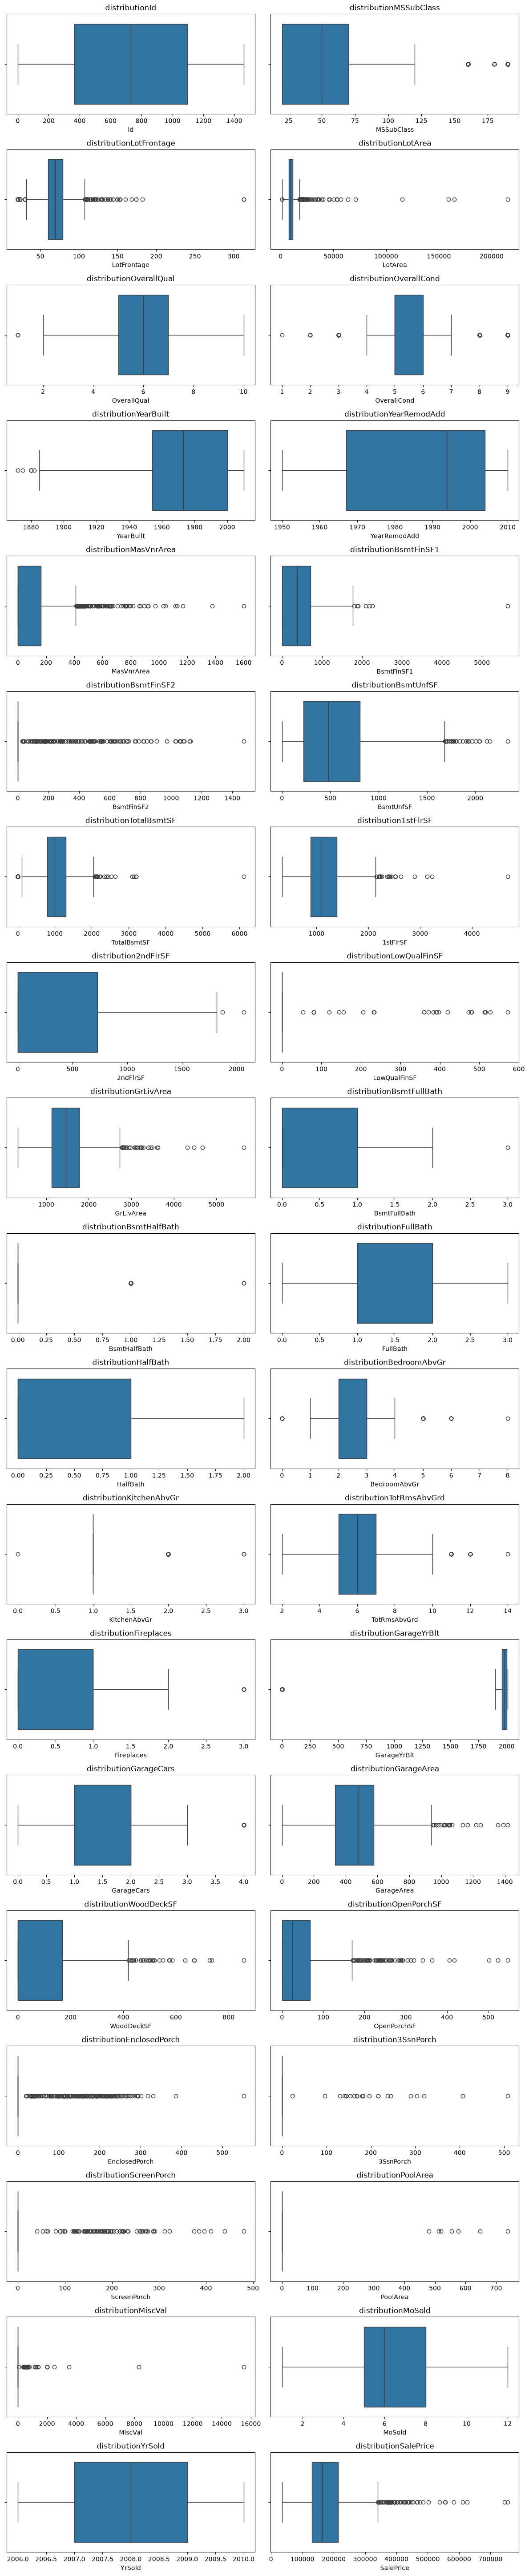

In [46]:
num_col = [col for col in df_tarin_clean.select_dtypes(include=(int,float)).columns]

plt.figure(figsize=(12,58))
for i,col in enumerate(num_col,1):
    plt.subplot(19,2,i)
    sns.boxplot(data=df_tarin_clean,x=col)
    plt.title(f"distribution{col}")
    
plt.tight_layout()
plt.show()

In [47]:
#handling outliers
def handle_outlier(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[f"capped_{col}"] = df[col].clip(lower=lower, upper = upper)

In [48]:
"""from the above observation i conclude that the are more no of house with some 
less feature so capping or handling it may affect the data quality 
and from the obervation there no such abnormal values in the numerical columns """

'from the above observation i conclude that the are more no of house with some \nless feature so capping or handling it may affect the data quality \nand from the obervation there no such abnormal values in the numerical columns '

In [49]:
from sklearn.preprocessing import OrdinalEncoder
df_train = pd.DataFrame()

In [50]:
ordinal_col ={"LotShape": ["IR3", "IR2", "IR1", "Reg"],
              "LandSlope": ["Sev", "Mod", "Gtl"],
              "ExterQual": ["Fa", "TA", "Gd", "Ex"],
              "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
              "BsmtQual": ["None", "Fa", "TA", "Gd", "Ex"],
              "BsmtCond": ["None", "Po", "Fa", "TA", "Gd"],
              "BsmtExposure": ["No", "Mn", "Av", "Gd"],
              "BsmtFinType1": ["No", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
              "BsmtFinType2": ["No", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
              "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
              "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
              "KitchenQual": ["Fa", "TA", "Gd", "Ex"],
              "Functional": ["Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
              "FireplaceQu": ["No", "Po", "Fa", "TA", "Gd", "Ex"],
              "GarageFinish": ["No", "Unf", "RFn", "Fin"],
              "GarageQual": ["No", "Po", "Fa", "TA", "Gd", "Ex"],
              "GarageCond": ["No", "Po", "Fa", "TA", "Gd", "Ex"],
              "PavedDrive": ["N", "P", "Y"],
              "PoolQC": ["No", "Fa", "TA", "Gd", "Ex"],
              "Fence": ["No", "MnWw", "GdWo", "MnPrv", "GdPrv"],}

df_tarin_clean["Fence"].unique()

<StringArray>
['No', 'MnPrv', 'GdWo', 'GdPrv', 'MnWw']
Length: 5, dtype: str

In [51]:
df_train = df_tarin_clean.copy()

for col in ordinal_col:
    encoder = OrdinalEncoder(categories=[ordinal_col[col]])
    df_train[[col]] = encoder.fit_transform(df_tarin_clean[[col]])
    
df_train[["LotShape",
              "LandSlope",
              "ExterQual",
              "ExterCond",
              "BsmtQual",
              "BsmtCond",
              "BsmtExposure",
              "BsmtFinType1",
              "BsmtFinType2",
              "HeatingQC",
              "HeatingQC",
              "KitchenQual",
              "Functional",
              "FireplaceQu",
              "GarageFinish",
              "GarageQual",
              "GarageCond",
              "PavedDrive",
              "PoolQC",
              "Fence"]]

df_train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,3.0,Lvl,AllPub,...,0,0.0,0.0,No,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,3.0,Lvl,AllPub,...,0,0.0,0.0,No,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,2.0,Lvl,AllPub,...,0,0.0,0.0,No,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,2.0,Lvl,AllPub,...,0,0.0,0.0,No,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,2.0,Lvl,AllPub,...,0,0.0,0.0,No,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,No Alley,3.0,Lvl,AllPub,...,0,0.0,0.0,No,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,No Alley,3.0,Lvl,AllPub,...,0,0.0,3.0,No,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,No Alley,3.0,Lvl,AllPub,...,0,0.0,4.0,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,No Alley,3.0,Lvl,AllPub,...,0,0.0,0.0,No,0,4,2010,WD,Normal,142125


In [52]:
onehot_cols = ["MSZoning","Street","Alley","LotConfig","Neighborhood","Condition1","Condition2","BldgType","HouseStyle","RoofStyle","RoofMatl",
    "Exterior1st","Exterior2nd","MasVnrType","Foundation","Heating","CentralAir","Electrical","GarageType","MiscFeature","SaleType",
    "SaleCondition","LandContour","Utilities"]

df_train = pd.get_dummies(df_train,columns=onehot_cols,dtype=int)

In [53]:
df_tarin_clean["RoofStyle"].unique()

<StringArray>
['Gable', 'Hip', 'Gambrel', 'Mansard', 'Flat', 'Shed']
Length: 6, dtype: str

In [54]:
df_train

,Id,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa
0,1,60,65.0,8450,3.0,2.0,7,5,2003,2003,...,0,0,1,0,0,0,0,1,1,0
1,2,20,80.0,9600,3.0,2.0,6,8,1976,1976,...,0,0,1,0,0,0,0,1,1,0
2,3,60,68.0,11250,2.0,2.0,7,5,2001,2002,...,0,0,1,0,0,0,0,1,1,0
3,4,70,60.0,9550,2.0,2.0,7,5,1915,1970,...,0,0,0,0,0,0,0,1,1,0
4,5,60,84.0,14260,2.0,2.0,8,5,2000,2000,...,0,0,1,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,3.0,2.0,6,5,1999,2000,...,0,0,1,0,0,0,0,1,1,0
1456,1457,20,85.0,13175,3.0,2.0,6,6,1978,1988,...,0,0,1,0,0,0,0,1,1,0
1457,1458,70,66.0,9042,3.0,2.0,7,9,1941,2006,...,0,0,1,0,0,0,0,1,1,0
1458,1459,20,68.0,9717,3.0,2.0,5,6,1950,1996,...,0,0,1,0,0,0,0,1,1,0


In [55]:
df_train['EnclosedPorch']

0         0
1         0
2         0
3       272
4         0
       ... 
1455      0
1456      0
1457      0
1458    112
1459      0
Name: EnclosedPorch, Length: 1460, dtype: int64

In [139]:
joblib.dump(df_train.columns.tolist(), "model_features.pkl")
joblib.dump(encoder,"ordinal_enkoder.pkl")

['ordinal_enkoder.pkl']

In [56]:
#test data

df_test_clean = pd.read_csv(r"../data/raw/test.csv")

df_test_clean

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [57]:
test_null_val =[(col,df_test_clean[col].isnull().sum()) for col in df_test_clean.columns if df_test_clean[col].isnull().sum() != 0]

In [58]:
df_test_clean["KitchenQual"].fillna(df_test_clean["KitchenQual"].mode()[0])

0       TA
1       Gd
2       TA
3       Gd
4       Gd
        ..
1454    TA
1455    TA
1456    TA
1457    TA
1458    TA
Name: KitchenQual, Length: 1459, dtype: str

In [59]:
df_test_clean[df_test_clean.duplicated]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition


In [60]:
df_test_clean["MSZoning"] = df_test_clean["MSZoning"].fillna(df_test_clean["MSZoning"].mode()[0])
df_test_clean["MSZoning"].isnull().sum()

np.int64(0)

In [61]:
#handling the lot frontage so filling it the tarin data set median

#mdeian is 69.0

In [62]:
df_test_clean["LotFrontage"] = df_test_clean["LotFrontage"].fillna(69.0)

df_test_clean["LotFrontage"].isnull().sum()

np.int64(0)

In [63]:
#handling alley 
#in tarin data filled witn No alley  so same here

In [64]:
df_test_clean['Alley'] = df_test_clean['Alley'].fillna("No Alley")

df_test_clean['Alley'].isnull().sum()

df_test_clean["Alley"].unique()
df_test_clean['Alley'].isnull().sum()

np.int64(0)

In [65]:
# utilites

df_test_clean["Utilities"].head()

df_test_clean["Utilities"].unique()

df_test_clean["Utilities"] = df_test_clean["Utilities"].fillna(df_test_clean["Utilities"].mode()[0])

In [66]:
#Exterior1st

df_test_clean["Exterior1st"] = df_test_clean["Exterior1st"].fillna(df_test_clean["Exterior1st"].mode()[0])
df_test_clean["Exterior1st"].isnull().sum()

np.int64(0)

In [67]:
#Exterior2nd
df_test_clean["Exterior2nd"] = df_test_clean["Exterior2nd"].fillna(df_test_clean["Exterior2nd"].mode()[0])
df_test_clean["Exterior2nd"].isnull().sum()

np.int64(0)

In [68]:
#filling masvnr type with none same as the train data

df_test_clean['MasVnrType'] = df_test_clean['MasVnrType'].fillna("None")

In [69]:
df_test_clean['MasVnrArea'] = df_test_clean['MasVnrArea'].fillna(0)
df_test_clean[df_test_clean["MasVnrArea"] == 0.0].loc[0:,["MasVnrType","MasVnrArea"]]

,MasVnrType,MasVnrArea
0,None,0.0
2,None,0.0
4,None,0.0
5,None,0.0
6,None,0.0
...,...,...
1453,None,0.0
1454,None,0.0
1455,None,0.0
1456,None,0.0


In [70]:
#basement qual is fill na with null

In [71]:
df_test_clean["BsmtQual"] = df_test_clean["BsmtQual"].fillna('None')
df_test_clean["BsmtQual"].isnull().sum()
df_test_clean["BsmtQual"].unique()

<StringArray>
['TA', 'Gd', 'Ex', 'Fa', 'None']
Length: 5, dtype: str

In [72]:
df_test_clean["BsmtFinType1"] = df_test_clean["BsmtFinType1"].fillna("No")

df_test_clean["BsmtFinType1"].unique()

<StringArray>
['Rec', 'ALQ', 'GLQ', 'Unf', 'BLQ', 'LwQ', 'No']
Length: 7, dtype: str

In [73]:
#BsmtFinSF1

df_test_clean["BsmtFinSF1"]
df_test_clean[df_test_clean["BsmtFinSF1"].isnull()].loc[0:,["BsmtFinType1","BsmtFinSF1"]]
# there is no basement so 0
df_test_clean["BsmtFinSF1"] = df_test_clean["BsmtFinSF1"].fillna(0)

In [74]:
#basement 2
df_test_clean["BsmtFinType2"] = df_test_clean["BsmtFinType2"].fillna("No")
df_test_clean["BsmtFinType2"].unique()

<StringArray>
['LwQ', 'Unf', 'Rec', 'BLQ', 'GLQ', 'ALQ', 'No']
Length: 7, dtype: str

In [75]:
df_test_clean["BsmtFinSF2"]
df_test_clean[df_test_clean["BsmtFinSF1"].isnull()].loc[0:,["BsmtFinType2","BsmtFinSF2"]]
# there is no basement so 0
df_test_clean["BsmtFinSF2"] = df_test_clean["BsmtFinSF2"].fillna(0)

In [76]:
df_test_clean[df_test_clean['BsmtUnfSF'].isnull()].loc[0: ,["BsmtQual","BsmtUnfSF"]]

df_test_clean["BsmtUnfSF"] = df_test_clean["BsmtUnfSF"].fillna(0)

In [77]:
#TotalBsmtSF
df_test_clean[df_test_clean['TotalBsmtSF'].isnull()].loc[0: ,["BsmtQual","TotalBsmtSF"]]

df_test_clean["TotalBsmtSF"] = df_test_clean["TotalBsmtSF"].fillna(0)

In [78]:
#BsmtFullBath
df_test_clean[df_test_clean['BsmtFullBath'].isnull()].loc[0: ,["BsmtQual","BsmtFullBath"]]

df_test_clean['BsmtFullBath'] =df_test_clean['BsmtFullBath'].fillna(0)

In [79]:
df_test_clean[df_test_clean['BsmtHalfBath'].isnull()].loc[0: ,["BsmtQual","BsmtHalfBath"]]

df_test_clean['BsmtHalfBath'] =df_test_clean['BsmtHalfBath'].fillna(0)

In [80]:
df_test_clean["BsmtCond"] = df_test_clean["BsmtCond"].fillna("None")
df_test_clean["BsmtExposure"] = df_test_clean["BsmtExposure"].fillna("No")

In [81]:
df_test_clean["KitchenQual"].unique()
df_test_clean["KitchenQual"] = df_test_clean["KitchenQual"].fillna(df_test_clean["KitchenQual"].mode()[0])

In [82]:
df_test_clean["Functional"] = df_test_clean["Functional"].fillna(df_test_clean["Functional"].mode()[0])
df_test_clean["Functional"].unique()

<StringArray>
['Typ', 'Min2', 'Min1', 'Mod', 'Maj1', 'Sev', 'Maj2']
Length: 7, dtype: str

In [83]:
df_test_clean["FireplaceQu"] = df_test_clean["FireplaceQu"].fillna("No")

In [84]:
test_null_val =[(col,df_test_clean[col].isnull().sum()) for col in df_test_clean.columns if df_test_clean[col].isnull().sum() != 0]

test_null_val

[('GarageType', np.int64(76)),
 ('GarageYrBlt', np.int64(78)),
 ('GarageFinish', np.int64(78)),
 ('GarageCars', np.int64(1)),
 ('GarageArea', np.int64(1)),
 ('GarageQual', np.int64(78)),
 ('GarageCond', np.int64(78)),
 ('PoolQC', np.int64(1456)),
 ('Fence', np.int64(1169)),
 ('MiscFeature', np.int64(1408)),
 ('SaleType', np.int64(1))]

In [85]:
df_test_clean["GarageType"] = df_test_clean["GarageType"].fillna("No")

In [86]:
df_test_clean['GarageYrBlt'] = df_test_clean["GarageYrBlt"].fillna(0)

df_test_clean["GarageYrBlt"].unique()

df_test_clean["GarageYrBlt"] =df_test_clean["GarageYrBlt"].astype(int)

In [87]:
df_test_clean['GarageFinish'] = df_test_clean["GarageFinish"].fillna("No")
df_test_clean["GarageFinish"].unique()

<StringArray>
['Unf', 'Fin', 'RFn', 'No']
Length: 4, dtype: str

In [88]:
df_test_clean["GarageCars"] = df_test_clean["GarageCars"].fillna(0)

In [89]:
df_test_clean["GarageArea"] = df_test_clean["GarageArea"].fillna(0)

In [90]:
df_test_clean["GarageQual"] = df_test_clean["GarageQual"].fillna("No")

df_test_clean["GarageQual"].unique()

<StringArray>
['TA', 'No', 'Fa', 'Gd', 'Po']
Length: 5, dtype: str

In [91]:
df_test_clean[df_test_clean["GarageCond"].isna()].loc[0:,["GarageCond","GarageQual","GarageType"]]

df_test_clean["GarageCond"] = df_test_clean["GarageCond"].fillna("No")

In [92]:
df_test_clean['PoolQC'] = df_test_clean['PoolQC'].fillna("No")

In [93]:
df_test_clean["Fence"] = df_test_clean["Fence"].fillna("No")

In [94]:
df_test_clean["MiscFeature"] = df_test_clean["MiscFeature"].fillna("No")

In [95]:
df_test_clean['SaleType'] = df_test_clean['SaleType'].fillna(df_test_clean['SaleType'].mode()[0])

In [96]:
df_test = pd.DataFrame()

In [97]:
ordinal_col ={"LotShape": ["IR3", "IR2", "IR1", "Reg"],
              "LandSlope": ["Sev", "Mod", "Gtl"],
              "ExterQual": ["Fa", "TA", "Gd", "Ex"],
              "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
              "BsmtQual": ["None", "Fa", "TA", "Gd", "Ex"],
              "BsmtCond": ["None", "Po", "Fa", "TA", "Gd"],
              "BsmtExposure": ["No", "Mn", "Av", "Gd"],
              "BsmtFinType1": ["No", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
              "BsmtFinType2": ["No", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
              "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
              "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
              "KitchenQual": ["Fa", "TA", "Gd", "Ex"],
              "Functional": ["Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
              "FireplaceQu": ["No", "Po", "Fa", "TA", "Gd", "Ex"],
              "GarageFinish": ["No", "Unf", "RFn", "Fin"],
              "GarageQual": ["No", "Po", "Fa", "TA", "Gd", "Ex"],
              "GarageCond": ["No", "Po", "Fa", "TA", "Gd", "Ex"],
              "PavedDrive": ["N", "P", "Y"],
              "PoolQC": ["No", "Fa", "TA", "Gd", "Ex"],
              "Fence": ["No", "MnWw", "GdWo", "MnPrv", "GdPrv"],}

df_test_clean["Fence"].unique()

<StringArray>
['MnPrv', 'No', 'GdPrv', 'GdWo', 'MnWw']
Length: 5, dtype: str

In [98]:
df_test = df_test_clean.copy()

for col in ordinal_col:
    encoder = OrdinalEncoder(categories=[ordinal_col[col]])
    df_test[[col]] = encoder.fit_transform(df_test_clean[[col]])

In [99]:
df_test[["LotShape",
              "LandSlope",
              "ExterQual",
              "ExterCond",
              "BsmtQual",
              "BsmtCond",
              "BsmtExposure",
              "BsmtFinType1",
              "BsmtFinType2",
              "HeatingQC",
              "HeatingQC",
              "KitchenQual",
              "Functional",
              "FireplaceQu",
              "GarageFinish",
              "GarageQual",
              "GarageCond",
              "PavedDrive",
              "PoolQC",
              "Fence"]]

,LotShape,LandSlope,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,HeatingQC,HeatingQC,KitchenQual,Functional,FireplaceQu,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence
0,3.0,2.0,1.0,2.0,2.0,3.0,0.0,3.0,2.0,2.0,2.0,1.0,6.0,0.0,1.0,3.0,3.0,2.0,0.0,3.0
1,2.0,2.0,1.0,2.0,2.0,3.0,0.0,5.0,1.0,2.0,2.0,2.0,6.0,0.0,1.0,3.0,3.0,2.0,0.0,0.0
2,2.0,2.0,1.0,2.0,3.0,3.0,0.0,6.0,1.0,3.0,3.0,1.0,6.0,3.0,3.0,3.0,3.0,2.0,0.0,3.0
3,2.0,2.0,1.0,2.0,2.0,3.0,0.0,6.0,1.0,4.0,4.0,2.0,6.0,4.0,3.0,3.0,3.0,2.0,0.0,0.0
4,2.0,2.0,2.0,2.0,3.0,3.0,0.0,5.0,1.0,4.0,4.0,2.0,6.0,0.0,2.0,3.0,3.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,3.0,2.0,1.0,2.0,2.0,3.0,0.0,1.0,1.0,3.0,3.0,1.0,6.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
1455,3.0,2.0,1.0,2.0,2.0,3.0,0.0,3.0,1.0,2.0,2.0,1.0,6.0,0.0,1.0,3.0,3.0,2.0,0.0,0.0
1456,3.0,2.0,1.0,2.0,2.0,3.0,0.0,5.0,1.0,4.0,4.0,1.0,6.0,3.0,1.0,3.0,3.0,2.0,0.0,0.0
1457,3.0,2.0,1.0,2.0,3.0,3.0,2.0,6.0,1.0,2.0,2.0,1.0,6.0,0.0,0.0,0.0,0.0,2.0,0.0,3.0


In [100]:
onehot_cols = ["MSZoning","Street","Alley","LotConfig","Neighborhood","Condition1","Condition2","BldgType","HouseStyle","RoofStyle","RoofMatl",
    "Exterior1st","Exterior2nd","MasVnrType","Foundation","Heating","CentralAir","Electrical","GarageType","MiscFeature","SaleType",
    "SaleCondition","LandContour","Utilities"]

df_test = pd.get_dummies(df_test,columns=onehot_cols,dtype=int)

In [101]:
print(df_test.columns.tolist())

df_test

['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'LandSlope', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence', 'MiscVal', 'MoSold', 'YrSold', 'MSZoning_C (all)', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Street_Grvl', 'Street_Pave', 'Alley_Grvl', 'Alley_No Alley', 'Alley_Pave', 'LotConfig_Corner', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3', 'LotC

,Id,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub
0,1461,20,80.0,11622,3.0,2.0,5,6,1961,1961,...,0,0,0,1,0,0,0,0,1,1
1,1462,20,81.0,14267,2.0,2.0,6,6,1958,1958,...,0,0,0,1,0,0,0,0,1,1
2,1463,60,74.0,13830,2.0,2.0,5,5,1997,1998,...,0,0,0,1,0,0,0,0,1,1
3,1464,60,78.0,9978,2.0,2.0,6,6,1998,1998,...,0,0,0,1,0,0,0,0,1,1
4,1465,120,43.0,5005,2.0,2.0,8,5,1992,1992,...,0,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,21.0,1936,3.0,2.0,4,7,1970,1970,...,0,0,0,1,0,0,0,0,1,1
1455,2916,160,21.0,1894,3.0,2.0,4,5,1970,1970,...,0,0,0,0,0,0,0,0,1,1
1456,2917,20,160.0,20000,3.0,2.0,5,7,1960,1996,...,0,0,0,0,0,0,0,0,1,1
1457,2918,85,62.0,10441,3.0,2.0,5,5,1992,1992,...,0,0,0,1,0,0,0,0,1,1


In [102]:
#filing the missing column

train_y = df_train["SalePrice"]
train_x = df_train.drop("SalePrice", axis=1)

In [103]:
train_x, df_test =train_x.align(df_test, join="left", axis=1, fill_value=0)

In [104]:
df_test.shape


(1459, 227)

In [105]:
train_x

,Id,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa
0,1,60,65.0,8450,3.0,2.0,7,5,2003,2003,...,0,0,1,0,0,0,0,1,1,0
1,2,20,80.0,9600,3.0,2.0,6,8,1976,1976,...,0,0,1,0,0,0,0,1,1,0
2,3,60,68.0,11250,2.0,2.0,7,5,2001,2002,...,0,0,1,0,0,0,0,1,1,0
3,4,70,60.0,9550,2.0,2.0,7,5,1915,1970,...,0,0,0,0,0,0,0,1,1,0
4,5,60,84.0,14260,2.0,2.0,8,5,2000,2000,...,0,0,1,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,3.0,2.0,6,5,1999,2000,...,0,0,1,0,0,0,0,1,1,0
1456,1457,20,85.0,13175,3.0,2.0,6,6,1978,1988,...,0,0,1,0,0,0,0,1,1,0
1457,1458,70,66.0,9042,3.0,2.0,7,9,1941,2006,...,0,0,1,0,0,0,0,1,1,0
1458,1459,20,68.0,9717,3.0,2.0,5,6,1950,1996,...,0,0,1,0,0,0,0,1,1,0


In [106]:
train_x = train_x.drop(columns="Id")

df_test_data = df_test.drop(columns="Id")

In [107]:
"""
    now we done encoding for each data set and separated feature 
    
    inputs are in  train_x
    
    target in    train_y
    
    test data set df_test_data
    
    """

'\n    now we done encoding for each data set and separated feature \n\n    inputs are in  train_x\n\n    target in    train_y\n\n    test data set df_test_data\n\n    '

In [108]:
train_x

,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa
0,60,65.0,8450,3.0,2.0,7,5,2003,2003,196.0,...,0,0,1,0,0,0,0,1,1,0
1,20,80.0,9600,3.0,2.0,6,8,1976,1976,0.0,...,0,0,1,0,0,0,0,1,1,0
2,60,68.0,11250,2.0,2.0,7,5,2001,2002,162.0,...,0,0,1,0,0,0,0,1,1,0
3,70,60.0,9550,2.0,2.0,7,5,1915,1970,0.0,...,0,0,0,0,0,0,0,1,1,0
4,60,84.0,14260,2.0,2.0,8,5,2000,2000,350.0,...,0,0,1,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,3.0,2.0,6,5,1999,2000,0.0,...,0,0,1,0,0,0,0,1,1,0
1456,20,85.0,13175,3.0,2.0,6,6,1978,1988,119.0,...,0,0,1,0,0,0,0,1,1,0
1457,70,66.0,9042,3.0,2.0,7,9,1941,2006,0.0,...,0,0,1,0,0,0,0,1,1,0
1458,20,68.0,9717,3.0,2.0,5,6,1950,1996,0.0,...,0,0,1,0,0,0,0,1,1,0


In [109]:
train_x[["LotFrontage","LotArea","MasVnrArea","BsmtFinSF1","TotalBsmtSF","1stFlrSF","GrLivArea","GarageArea"]].skew()

LotFrontage     2.409147
LotArea        12.207688
MasVnrArea      2.677616
BsmtFinSF1      1.685503
TotalBsmtSF     1.524255
1stFlrSF        1.376757
GrLivArea       1.366560
GarageArea      0.179981
dtype: float64

In [110]:
train_x["TotalBsmtSF"].skew()

np.float64(1.5242545490627664)

In [111]:
skew_list =["LotFrontage","LotArea","MasVnrArea","BsmtFinSF1","1stFlrSF","GrLivArea"]

for col in skew_list:
    train_x[col] = np.log1p(train_x[col])

In [112]:
train_x[["LotFrontage","LotArea","MasVnrArea","BsmtFinSF1","TotalBsmtSF","1stFlrSF","GrLivArea","GarageArea"]].skew()

LotFrontage   -0.870006
LotArea       -0.137404
MasVnrArea     0.503532
BsmtFinSF1    -0.618410
TotalBsmtSF    1.524255
1stFlrSF       0.080114
GrLivArea     -0.006140
GarageArea     0.179981
dtype: float64

In [113]:
df_test_data[["LotFrontage","LotArea","MasVnrArea","BsmtFinSF1","1stFlrSF","GrLivArea"]].skew()

LotFrontage    0.710591
LotArea        3.115217
MasVnrArea     2.549569
BsmtFinSF1     1.166330
1stFlrSF       1.558195
GrLivArea      1.130402
dtype: float64

In [114]:
skew_list =["LotFrontage","LotArea","MasVnrArea","BsmtFinSF1","1stFlrSF","GrLivArea"]
for col in skew_list:
    df_test_data[col] = np.log1p(df_test_data[col])

In [115]:
df_test_data[["LotFrontage","LotArea","MasVnrArea","BsmtFinSF1","1stFlrSF","GrLivArea"]].skew()

LotFrontage   -1.138210
LotArea       -0.915598
MasVnrArea     0.572067
BsmtFinSF1    -0.616148
1stFlrSF       0.053499
GrLivArea      0.028376
dtype: float64

In [116]:
#feature engineering

#house age 

train_x["HouseAge"] = train_x["YrSold"] -train_x["YearBuilt"]

#remodel age 

train_x["RemodelAge"] = train_x["YrSold"] - train_x["YearRemodAdd"]

#total sf

train_x["TotalSf"] = train_x["TotalBsmtSF"] +train_x['1stFlrSF'] +train_x['2ndFlrSF']

#total bathrroms
train_x["TotalBathrooms"] = train_x["FullBath"] + 0.5 * train_x['HalfBath'] + train_x['BsmtFullBath']+ 0.5*train_x['BsmtHalfBath']

#total living area
train_x["TotalLivArea"] = train_x['GrLivArea'] + train_x['TotalBsmtSF']

In [117]:
train_x

,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,HouseAge,RemodelAge,TotalSf,TotalBathrooms,TotalLivArea
0,60,4.189655,9.042040,3.0,2.0,7,5,2003,2003,5.283204,...,0,0,1,1,0,5,5,1716.753438,3.5,863.444833
1,20,4.394449,9.169623,3.0,2.0,6,8,1976,1976,0.000000,...,0,0,1,1,0,31,31,1269.141245,2.5,1269.141245
2,60,4.234107,9.328212,2.0,2.0,7,5,2001,2002,5.093750,...,0,0,1,1,0,7,6,1792.825460,3.5,927.488294
3,70,4.110874,9.164401,2.0,2.0,7,5,1915,1970,0.000000,...,0,0,1,1,0,91,36,1518.869014,2.0,763.448916
4,60,4.442651,9.565284,2.0,2.0,8,5,2000,2000,5.860786,...,0,0,1,1,0,8,8,2205.044033,3.5,1152.695758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,4.143135,8.976894,3.0,2.0,6,5,1999,2000,0.000000,...,0,0,1,1,0,8,7,1653.860664,2.5,960.407318
1456,20,4.454347,9.486152,3.0,2.0,6,6,1978,1988,4.787492,...,0,0,1,1,0,32,22,1549.637234,3.0,1549.637234
1457,70,4.204693,9.109746,3.0,2.0,7,9,1941,2006,0.000000,...,0,0,1,1,0,69,4,2311.080868,2.0,1159.758333
1458,20,4.234107,9.181735,3.0,2.0,5,6,1950,1996,0.000000,...,0,0,1,1,0,60,14,1084.983790,2.0,1084.983790


In [118]:
#fearure enginering for the test data set
df_test_data["HouseAge"] = df_test_data["YrSold"] -df_test_data["YearBuilt"]

#remodel age 

df_test_data["RemodelAge"] = df_test_data["YrSold"] - df_test_data["YearRemodAdd"]

#total sf

df_test_data["TotalSf"] = df_test_data["TotalBsmtSF"] +df_test_data['1stFlrSF'] + df_test_data['2ndFlrSF']

#total bathrroms
df_test_data["TotalBathrooms"] = df_test_data["FullBath"] + 0.5 * df_test_data['HalfBath'] + df_test_data['BsmtFullBath']+ 0.5*train_x['BsmtHalfBath']

#total living area
df_test_data["TotalLivArea"] = df_test_data['GrLivArea'] + df_test_data['TotalBsmtSF']

In [119]:
print(set(df_test_data.columns) -set(train_x.columns))

print(set(train_x.columns) - set(df_test_data.columns))

set()
set()


In [120]:
#feature selection

merger_df = pd.concat([train_x,train_y],axis=1)

In [121]:
cor_matrix = merger_df.corr()["SalePrice"]

car_dict = cor_matrix.to_dict()

cor_matrix

MSSubClass       -0.084284
LotFrontage       0.332477
LotArea           0.388528
LotShape         -0.267759
LandSlope        -0.051152
                    ...   
RemodelAge       -0.509079
TotalSf           0.726778
TotalBathrooms    0.631731
TotalLivArea      0.613905
SalePrice         1.000000
Name: SalePrice, Length: 232, dtype: float64

In [122]:
val = [(name,car_dict[name]) for name in merger_df.columns if abs(car_dict[name])>0.30]

val

selected_col =[name for name in merger_df.columns if abs(car_dict[name])>0.30]
selected_col

['LotFrontage',
 'LotArea',
 'OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'ExterQual',
 'BsmtQual',
 'BsmtExposure',
 'BsmtFinType1',
 'TotalBsmtSF',
 'HeatingQC',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'FullBath',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Fireplaces',
 'FireplaceQu',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'Neighborhood_NoRidge',
 'Neighborhood_NridgHt',
 'Exterior1st_VinylSd',
 'Exterior2nd_VinylSd',
 'MasVnrType_None',
 'MasVnrType_Stone',
 'Foundation_CBlock',
 'Foundation_PConc',
 'GarageType_Attchd',
 'GarageType_Detchd',
 'SaleType_New',
 'SaleCondition_Partial',
 'HouseAge',
 'RemodelAge',
 'TotalSf',
 'TotalBathrooms',
 'TotalLivArea',
 'SalePrice']

In [123]:
selected_train_x = pd.DataFrame()

selected_col.pop()

'SalePrice'

In [124]:
for col in selected_col:
    selected_train_x[col] = train_x[col]

selected_train_x

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,BsmtQual,BsmtExposure,BsmtFinType1,...,Foundation_PConc,GarageType_Attchd,GarageType_Detchd,SaleType_New,SaleCondition_Partial,HouseAge,RemodelAge,TotalSf,TotalBathrooms,TotalLivArea
0,4.189655,9.042040,7,2003,2003,5.283204,2.0,3.0,0.0,6.0,...,1,1,0,0,0,5,5,1716.753438,3.5,863.444833
1,4.394449,9.169623,6,1976,1976,0.000000,1.0,3.0,3.0,5.0,...,0,1,0,0,0,31,31,1269.141245,2.5,1269.141245
2,4.234107,9.328212,7,2001,2002,5.093750,2.0,3.0,1.0,6.0,...,1,1,0,0,0,7,6,1792.825460,3.5,927.488294
3,4.110874,9.164401,7,1915,1970,0.000000,1.0,2.0,0.0,5.0,...,0,0,1,0,0,91,36,1518.869014,2.0,763.448916
4,4.442651,9.565284,8,2000,2000,5.860786,2.0,3.0,2.0,6.0,...,1,1,0,0,0,8,8,2205.044033,3.5,1152.695758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,4.143135,8.976894,6,1999,2000,0.000000,1.0,3.0,0.0,1.0,...,1,1,0,0,0,8,7,1653.860664,2.5,960.407318
1456,4.454347,9.486152,6,1978,1988,4.787492,1.0,3.0,0.0,5.0,...,0,1,0,0,0,32,22,1549.637234,3.0,1549.637234
1457,4.204693,9.109746,7,1941,2006,0.000000,3.0,2.0,0.0,6.0,...,0,1,0,0,0,69,4,2311.080868,2.0,1159.758333
1458,4.234107,9.181735,5,1950,1996,0.000000,1.0,2.0,1.0,6.0,...,0,1,0,0,0,60,14,1084.983790,2.0,1084.983790


In [125]:
selected_test = pd.DataFrame()

In [126]:
for col in selected_col:
    selected_test[col] = df_test_data[col]

selected_test

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,BsmtQual,BsmtExposure,BsmtFinType1,...,Foundation_PConc,GarageType_Attchd,GarageType_Detchd,SaleType_New,SaleCondition_Partial,HouseAge,RemodelAge,TotalSf,TotalBathrooms,TotalLivArea
0,4.394449,9.360741,5,1961,1961,0.000000,1.0,2.0,0.0,3.0,...,0,1,0,0,0,49,49,888.799056,1.0,888.799056
1,4.406719,9.565775,6,1958,1958,4.691348,1.0,2.0,0.0,5.0,...,0,1,0,0,0,52,52,1336.192934,2.0,1336.192934
2,4.317488,9.534668,5,1997,1998,0.000000,1.0,3.0,0.0,6.0,...,1,1,0,0,0,13,12,1635.834109,2.5,935.396335
3,4.369448,9.208238,6,1998,1998,3.044522,1.0,2.0,0.0,6.0,...,1,1,0,0,0,12,12,1610.831954,2.5,933.380879
4,3.784190,8.518392,8,1992,1992,0.000000,2.0,3.0,0.0,5.0,...,1,1,0,0,0,18,18,1287.155396,2.0,1287.155396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,3.091042,7.568896,4,1970,1970,0.000000,1.0,2.0,0.0,1.0,...,0,0,0,0,0,36,36,1098.304449,1.5,552.996681
1455,3.091042,7.546974,4,1970,1970,0.000000,1.0,2.0,0.0,3.0,...,0,0,0,0,0,36,36,1098.304449,1.5,552.996681
1456,5.081404,9.903538,5,1960,1996,0.000000,1.0,2.0,0.0,5.0,...,0,0,1,0,0,46,10,1231.110696,2.0,1231.110696
1457,4.143135,9.253591,5,1992,1992,0.000000,1.0,3.0,2.0,6.0,...,1,0,0,0,0,14,14,918.878326,1.0,918.878326


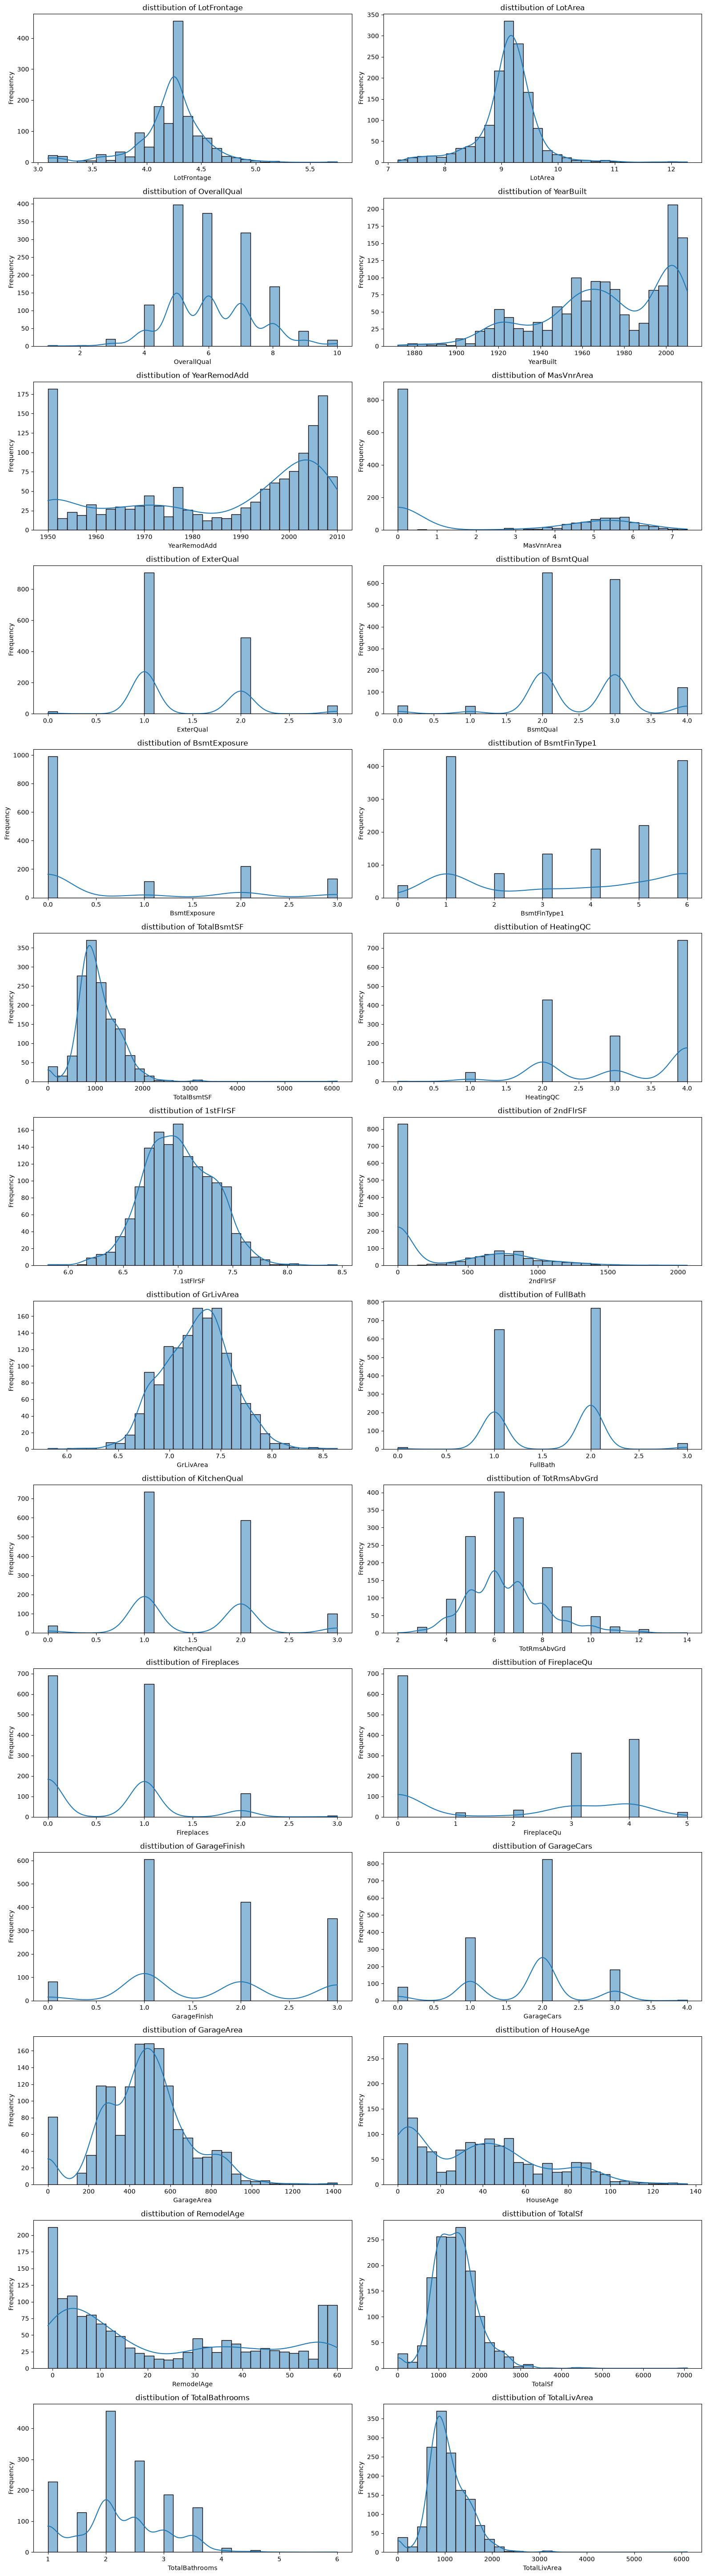

In [127]:
#distribution comparasion for selected features 

columns= ['LotFrontage',
 'LotArea',
 'OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'ExterQual',
 'BsmtQual',
 'BsmtExposure',
 'BsmtFinType1',
 'TotalBsmtSF',
 'HeatingQC',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'FullBath',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Fireplaces',
 'FireplaceQu',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'HouseAge',
 'RemodelAge',
 'TotalSf',
 'TotalBathrooms',
 'TotalLivArea',]

plt.figure(figsize=(16,58))

for i,col in enumerate(columns,1) :
    plt.subplot(14,2,i)
    
    sns.histplot(data=selected_train_x,x=col,kde=True,bins=30)
    plt.title(f"disttibution of {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

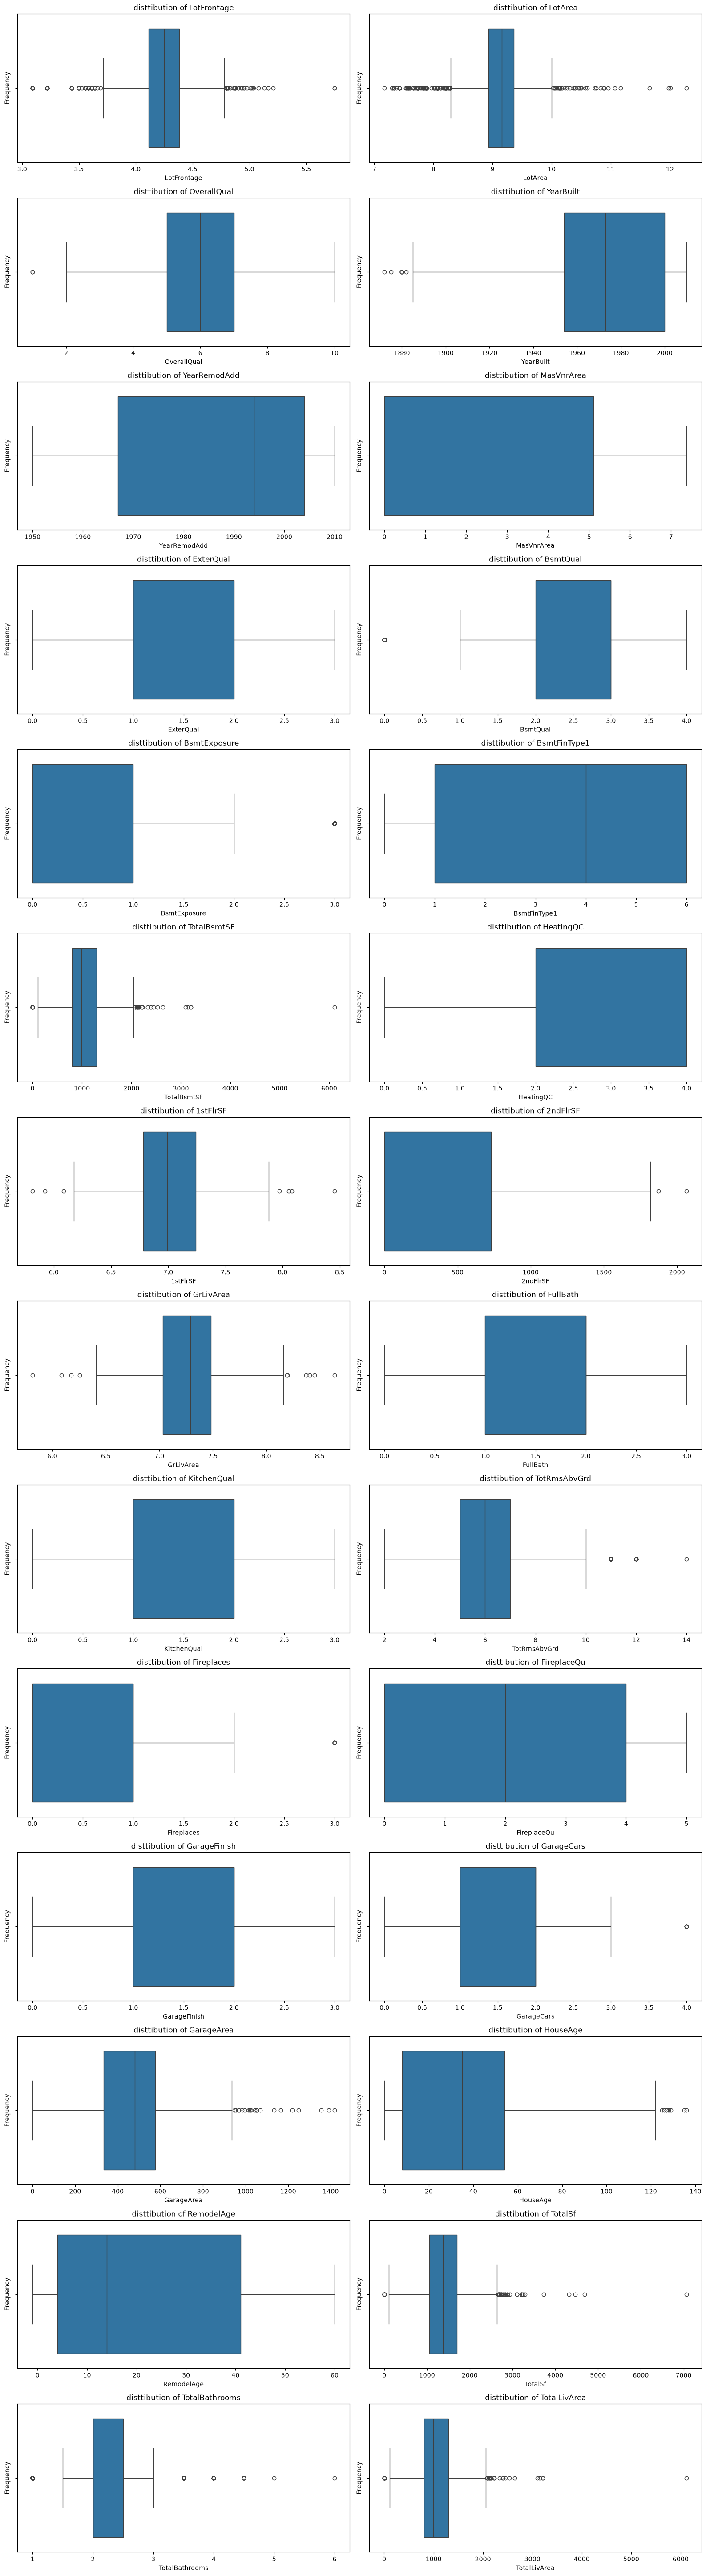

In [128]:
plt.figure(figsize=(16,58))

for i,col in enumerate(columns,1) :
    plt.subplot(14,2,i)
    
    sns.boxplot(data=selected_train_x,x=col)
    plt.title(f"disttibution of {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [129]:
merger_df = pd.concat([selected_train_x,train_y],axis=1)

corr_matrix = merger_df.corr()

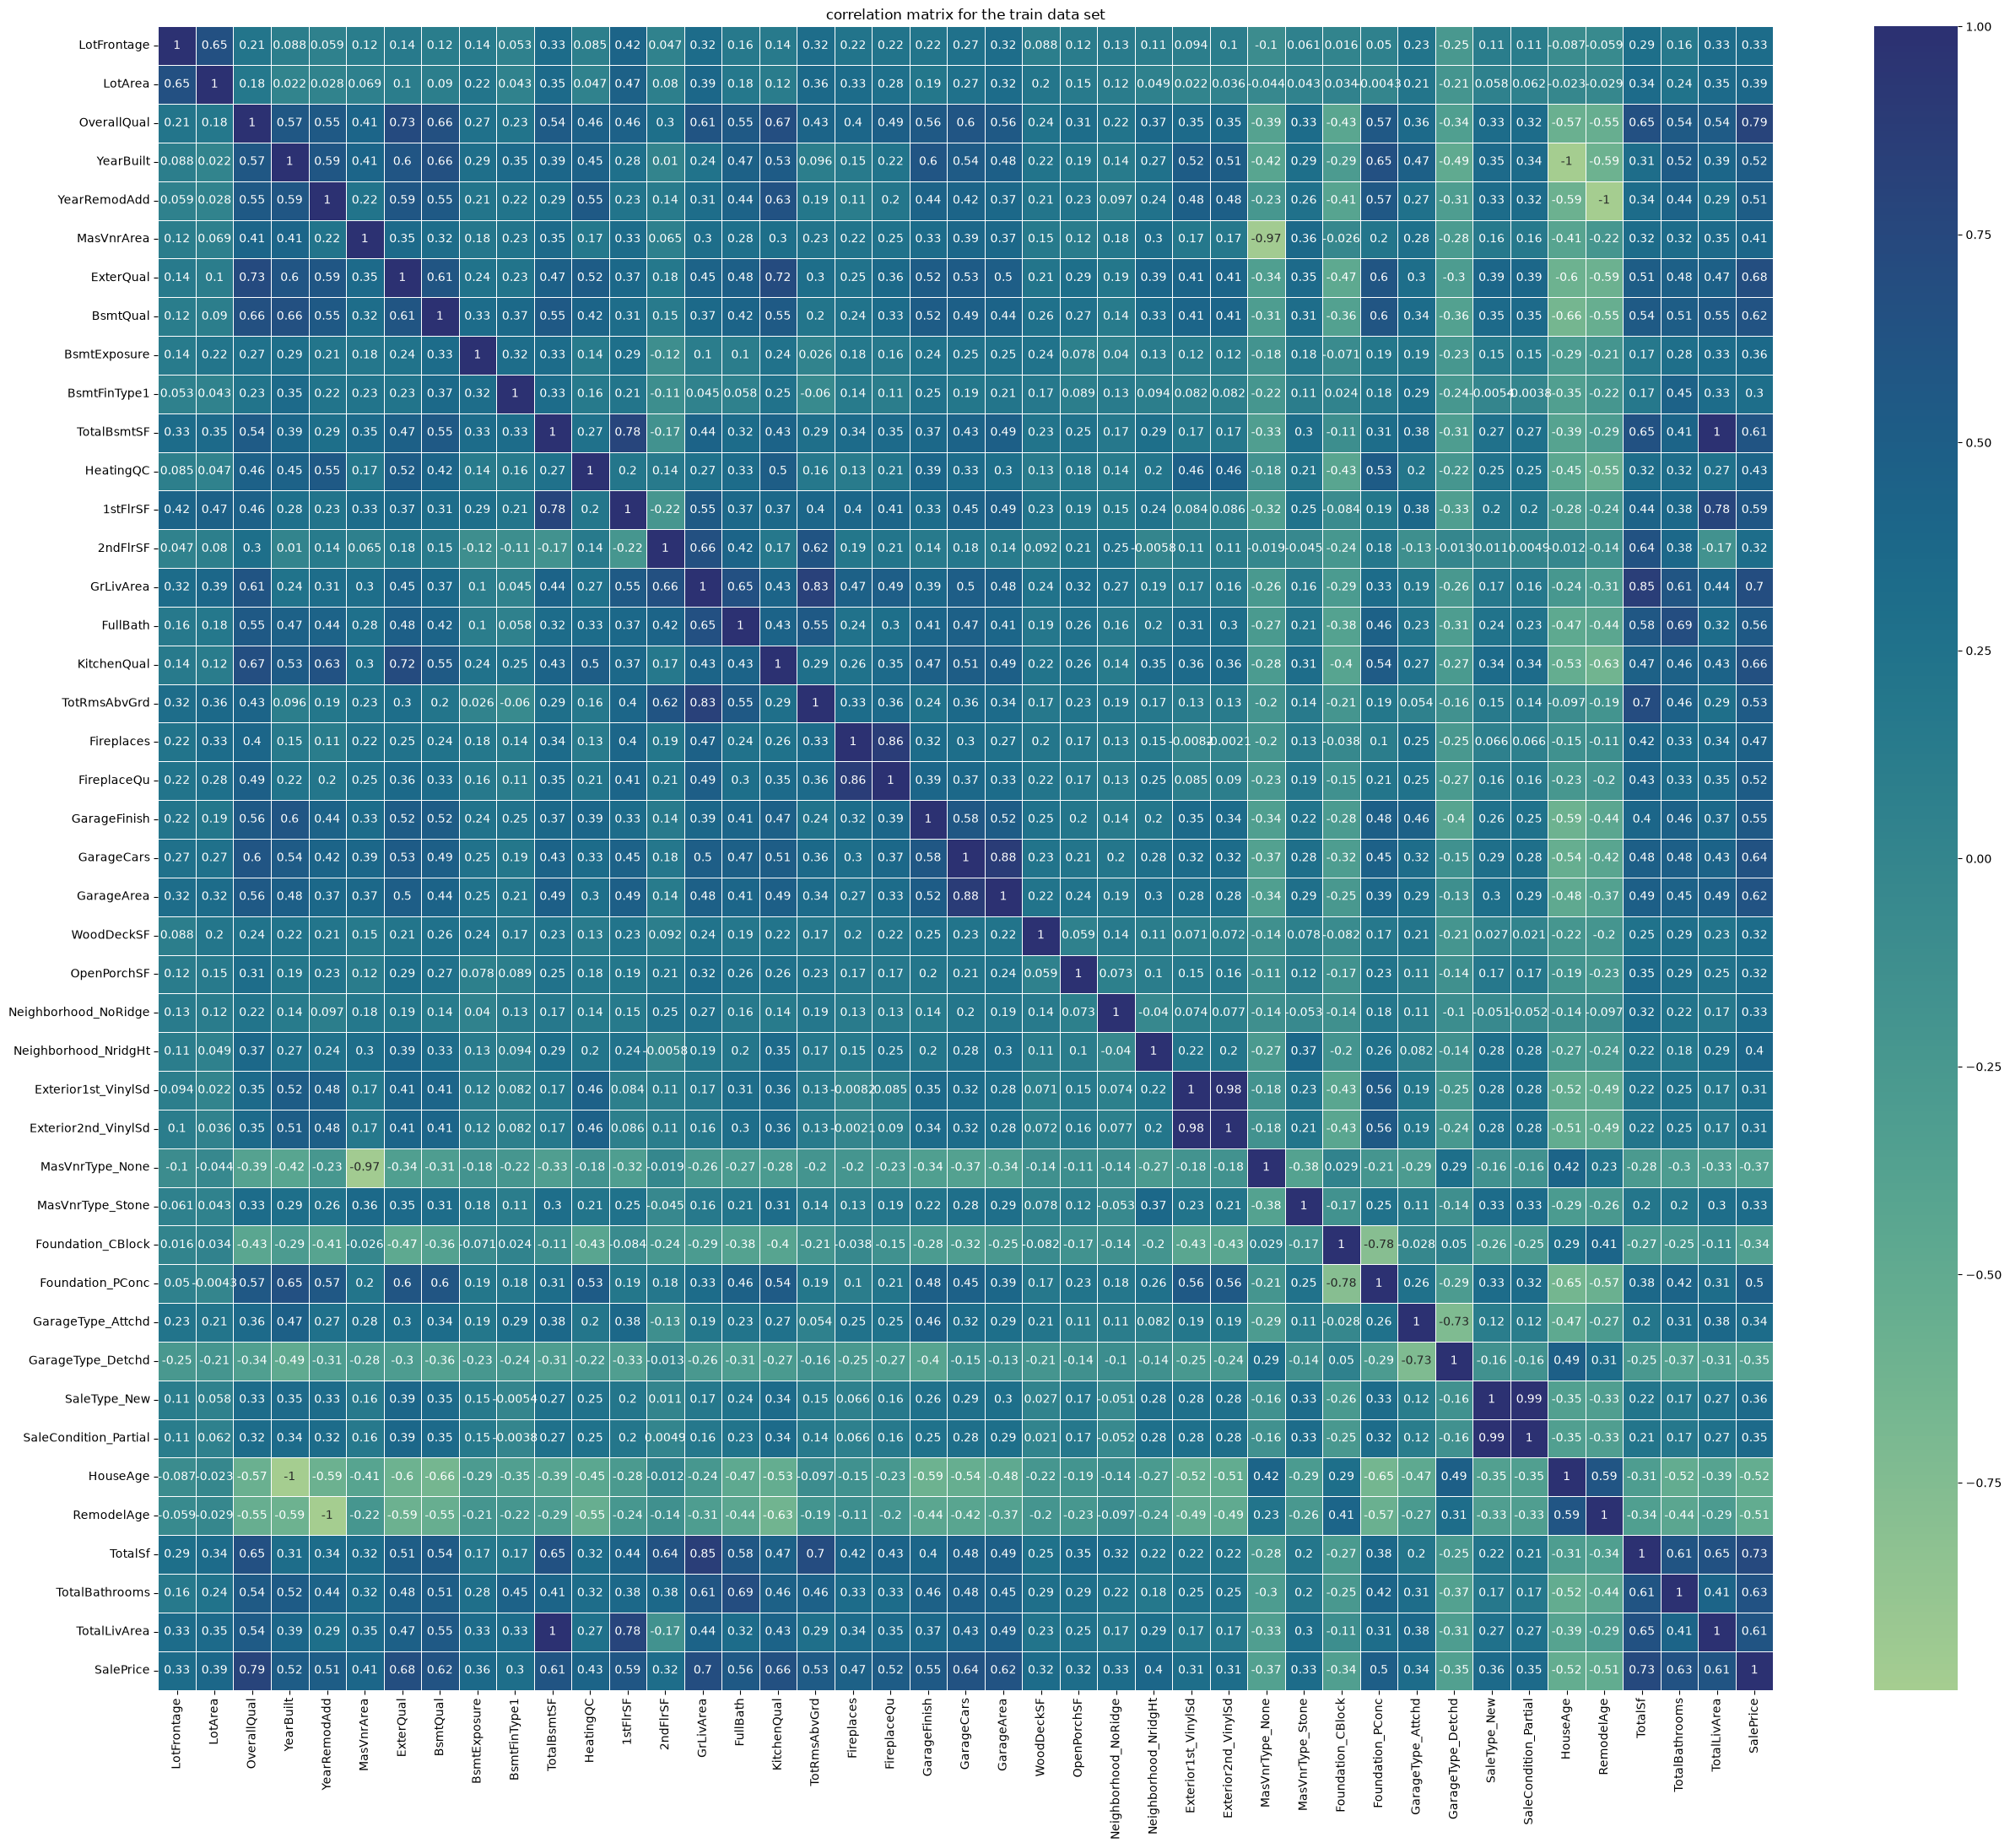

In [130]:
plt.figure(figsize=(26,22))

sns.heatmap(corr_matrix,annot=True,cmap="crest",linewidths=0.5)

plt.title("correlation matrix for the train data set")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [131]:
"""
selected 43 col to train the model 

x= selected_train_x

y= train_y

test data set

selected_test

selected_test
"""

"""
    now we done encoding for each data set and separated feature 
    
    inputs are in  train_x
    
    target in    train_y
    
    test data set df_test_data
    
    """

'\n    now we done encoding for each data set and separated feature \n\n    inputs are in  train_x\n\n    target in    train_y\n\n    test data set df_test_data\n\n    '

In [132]:
df_tarin_clean.to_csv(r"../data/cleaned/cleand_train.csv",index=False)

In [133]:
df_test_clean.to_csv(r"../data/cleaned/cleand_test.csv",index=False)

In [134]:
df_train

,Id,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa
0,1,60,65.0,8450,3.0,2.0,7,5,2003,2003,...,0,0,1,0,0,0,0,1,1,0
1,2,20,80.0,9600,3.0,2.0,6,8,1976,1976,...,0,0,1,0,0,0,0,1,1,0
2,3,60,68.0,11250,2.0,2.0,7,5,2001,2002,...,0,0,1,0,0,0,0,1,1,0
3,4,70,60.0,9550,2.0,2.0,7,5,1915,1970,...,0,0,0,0,0,0,0,1,1,0
4,5,60,84.0,14260,2.0,2.0,8,5,2000,2000,...,0,0,1,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,3.0,2.0,6,5,1999,2000,...,0,0,1,0,0,0,0,1,1,0
1456,1457,20,85.0,13175,3.0,2.0,6,6,1978,1988,...,0,0,1,0,0,0,0,1,1,0
1457,1458,70,66.0,9042,3.0,2.0,7,9,1941,2006,...,0,0,1,0,0,0,0,1,1,0
1458,1459,20,68.0,9717,3.0,2.0,5,6,1950,1996,...,0,0,1,0,0,0,0,1,1,0


In [135]:
df_test.to_csv(r"../data/encoded/encoded_test.csv",index=False)
df_train.to_csv(r"../data/encoded/encoded_train.csv",index=False)

In [136]:
selected_train_x.to_csv(r"../data/selected/selcetd_train_x.csv")
selected_test.to_csv(r"../data/selected/selcetd_test.csv")
train_y.to_csv(r"../data/selected/train_y.csv")